In [1]:
import cobra
from cobra.io import read_sbml_model
from cobra.sampling import sample
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Simulations for O'Quinn et al 2026

## Model simulation helper functions

In [2]:
def create_rxn(model, name, cpd_dict, direction="both", limits=None):
    # Create a reaction from a dict with {"CPD1": -1, "CPD2: 1"}
    # Assuming the cpd ids are already in the model
    if direction not in ["forward", "reverse", "both"]:
        raise ValueError("Direction must be either forward, reverse, or both")
    rxn = cobra.Reaction(name)
    if limits is not None:
        if len(limits) != 2:
            raise ValueError("Limits must be of length 2")
        else:
            rxn.lower_bound = limits[0]
            rxn.upper_bound = limits[1]
    elif direction == "both":
        rxn.lower_bound = -1000
        rxn.upper_bound = 1000
    elif direction == "forward":
        rxn.lower_bound = 0
        rxn.upper_bound = 1000
    else:
        rxn.lower_bound = -1000
        rxn.upper_bound = 0
    rxn.add_metabolites({
        getattr(model.metabolites, cpd): val for cpd, val in cpd_dict.items()
    })
    print("Adding the following reaction to model:")
    print(rxn)
    model.add_reactions([rxn])

def plt_contributing_rxns(model, sample, cpd_id, n=10, scale=None):
    rxns = [x.id for x in getattr(model.metabolites, cpd_id).reactions]
    raw_means = sample[rxns].mean(axis=0)
    errors = sample[rxns].std(axis=0)
    for rxn in raw_means.index:
        direction = {cpd.id:val for cpd,val
                     in getattr(model.reactions, rxn).metabolites.items()}[cpd_id]
        raw_means[rxn] = raw_means[rxn]*direction
    topn = pd.concat([raw_means.sort_values(ascending=False).head(n),
                      raw_means.sort_values(ascending=False).tail(n)])
    print(raw_means[raw_means > 0].sum())
    if all(np.isnan(errors)):
        plt.bar(topn.index, topn)
    else:
        plt.bar(topn.index, topn, yerr=errors[topn.index])
    plt.xticks(rotation="vertical")
    if scale is not None:
        plt.yscale(scale)
    plt.tight_layout()
    plt.show()
    
def add_fixed_constraint(model, rxn, value):
    """
    model = cobra formatted model
    rxn = string of reaction id
    value = a single int/float to constrain the reaction to, or a list/tuple like (lb, ub)
    """
    try:
        lower = value[0]
        upper = value[1]
    except (TypeError, IndexError):
        lower = value
        upper = value
    constraint = model.problem.Constraint(
        getattr(model.reactions, rxn).flux_expression,
        lb=lower, ub=upper)
    model.add_cons_vars(constraint)
    return constraint

def plt_hist(*data, rxn=None, bins=20, labels=None, xlabel=None):
    # if rxn is not specified, it will treat the data as arrays
    # otherwise it will treat it as dataframes and subset rxn from them
    if labels is not None and len(data) != len(labels):
        raise ValueError("labels and data must be lists of same length")
    if labels is None:
        labels2 = [None]*len(data)
    else:
        labels2 = labels
    # parse data:
    if rxn is not None:
        arrays = [df[rxn] for df in data]
    else:
        arrays = data
    if type(bins) == int:
        binz = np.linspace(min(np.concatenate(arrays)),
                           max(np.concatenate(arrays)),
                           bins)
    elif len(bins) == 3:
        binz = np.linspace(bins[0], bins[1], bins[2])
    else:
        raise ValueError("Bins must be an integer (number of bins) or a " +
                         "list/tuple of length three; (min, max, nbins)")
    for arr,lab in zip(arrays,labels2):
        plt.hist(arr, bins=binz, label=lab, alpha=0.4, edgecolor="black")
    if labels is not None:
        plt.legend()
    if xlabel is None:
        plt.xlabel(rxn)
    else:
        plt.xlabel(xlabel)
    plt.show()

def get_stoichiometric_contribution(flux_sample, compound_id, model):
    """
    Adjusts the fluxes in your sample to represent the flux of a specific compound
    """
    # Create copy df with all zeros
    new_sample = pd.DataFrame().reindex_like(flux_sample).replace(np.nan, 0)
    for reaction in getattr(model.metabolites, compound_id).reactions:
        new_sample[reaction.id] = flux_sample[reaction.id] * reaction.get_coefficient(compound_id)
    return new_sample

def transform_to_scaled_proportion(row):
    total_flux = np.sum(np.abs(row))/2
    return row/total_flux

In [3]:
def get_phosphorylation_contribution(flux_sample, model):
    """
    Calculates the net phosphorylation state change for each reaction.
    Tracks all nucleotides (ATP, GTP, CTP, UTP, etc.) and free phosphates.
    
    Returns a DataFrame where each value represents the net high-energy 
    phosphate bonds produced (positive) or consumed (negative).
    """
    
    # Define phosphorylation states
    # These are common KEGG/BiGG IDs - adjust for your model
    nucleotide_triphosphates = {
        'C00002': 'atp',    # ATP
        'C00044': 'gtp',    # GTP  
        'C00063': 'ctp',    # CTP
        'C00075': 'utp',    # UTP
        'C00081': 'itp',    # ITP
        'C00131': 'dttp',   # dTTP
        'C00286': 'datp',   # dATP
        'C00459': 'dgtp',   # dGTP
        'C00458': 'dctp',   # dCTP
        'C01345': 'ditp',   # dITP
    }
    
    nucleotide_diphosphates = {
        'C00008': 'adp',    # ADP
        'C00035': 'gdp',    # GDP
        'C00112': 'cdp',    # CDP
        'C00015': 'udp',    # UDP
        'C00104': 'idp',    # IDP
        'C00206': 'dtdp',   # dTDP
        'C00206': 'dadp',   # dADP
        'C00361': 'dgdp',   # dGDP
        'C00705': 'dcdp',   # dCDP
        'C01344': 'didp',   # dIDP
    }
    
    nucleotide_monophosphates = {
        'C00020': 'amp',    # AMP
        'C00144': 'gmp',    # GMP
        'C00055': 'cmp',    # CMP
        'C00105': 'ump',    # UMP
        'C00130': 'imp',    # IMP
        'C00364': 'dtmp',   # dTMP
        'C00413': 'damp',   # dAMP
        'C00362': 'dgmp',   # dGMP
        'C01081': 'dcmp',   # dCMP
        'C06196': 'dimp',   # dIMP
    }
    
    phosphates = {
        'C00009': 'pi',     # Phosphate (Pi)
        'C00013': 'ppi',    # Pyrophosphate (PPi)
    }
    
    # Assign phosphorylation values
    phosphate_values = {}
    for cpd_id in nucleotide_triphosphates.keys():
        phosphate_values[cpd_id] = 2  # 2 high-energy bonds
    for cpd_id in nucleotide_diphosphates.keys():
        phosphate_values[cpd_id] = 1  # 1 high-energy bond
    for cpd_id in nucleotide_monophosphates.keys():
        phosphate_values[cpd_id] = 0  # 0 high-energy bonds
    phosphate_values['C00009'] = 0   # Pi - no high-energy bond
    phosphate_values['C00013'] = 1   # PPi - 1 high-energy bond
    
    # Calculate net phosphorylation for each reaction
    new_sample = pd.DataFrame().reindex_like(flux_sample).replace(np.nan, 0)
    
    for reaction in model.reactions:
        # Calculate net phosphorylation state change
        net_phosphorylation = 0
        
        for metabolite, coefficient in reaction.metabolites.items():
            met_id = metabolite.id
            
            # Check if this metabolite contributes to phosphorylation state
            if met_id in phosphate_values:
                # Positive coefficient = product (increases if value is positive)
                # Negative coefficient = reactant (decreases if value is positive)
                net_phosphorylation += coefficient * phosphate_values[met_id]
        
        # Multiply by flux to get contribution
        new_sample[reaction.id] = flux_sample[reaction.id] * net_phosphorylation
    
    return new_sample



## Loading model and constraining the experimental data

In [4]:
#cobra_model = read_sbml_model("/home/jason_vailionis_uri_edu/git/GEM-iPfu/sbmls/30abaf5_BDO_cellobiose.sbml")
cobra_model = read_sbml_model("/home/jason_vailionis_uri_edu/git/GEM-iPfu/sbmls/5564dbe3_bdo_cellobiose.sbml")
constraint_data = pd.read_table("/work/pi_yingzhang_uri_edu/jvailionis/data/2026-03-03_PFU_BDO_carbon_closure.tsv")

'' is not a valid SBML 'SId'.


In [5]:
# Disables gluconeogenesis reactions
#cobra_model.reactions.R04780_zws.upper_bound = 0
#cobra_model.reactions.R01512.bounds = (0, 0)

In [5]:
outdir = '/work/pi_yingzhang_uri_edu/jvailionis/figs/S2026_Hailey_BDO_manuscript/'

In [6]:
# Create a model for each strain
# Constrain the data to be mean +/- stderr
models = {strain: cobra_model.copy()
          for strain in constraint_data["strain"].unique()}

for _, row in constraint_data.iterrows():
    # Skip constraining CO2; this is calculated from other products anyways
    if row["id_cobra"] == "TP_CO2":
        continue
    reaction = getattr(models[row["strain"]].reactions, row["id_cobra"])
    reaction.bounds = (row["lb"], row["ub"])
    #if (row["name"] == "Glucose") and (row["strain"] == "COM1c"):
    #    reaction.bounds = (5, 1000)     # Manually handling glucose cuz of data weirdness
    #else:
    #    reaction.bounds = (row["lb"], row["ub"])

Verifying that the models are feasible under the constraints

In [7]:
for strain, model in models.items():
    try:
        model.optimize()
        cobra.util.assert_optimal(model)
    except (cobra.exceptions.Infeasible, cobra.exceptions.OptimizationError) as e:
        print(f"{strain} failed: {e}")
    else:
        print(f"{strain} passed")

MW698 passed
MW697 passed
MW268 passed
COM1c passed


# Flux sampling

In [8]:
import pickle
import os

with open(os.path.join(outdir, "samples_dict.pkl"), 'rb') as f:
    samples = pickle.load(f)

In [9]:
# Random sampling of all the models
samples = {
    strain: sample(model, 5000, processes=4)
    for strain, model in models.items()
}

In [61]:
import pickle
import os

with open(os.path.join(outdir, "samples_dict.pkl"), 'wb') as f:
    pickle.dump(samples, f)

In [9]:
samples_c_adjusted = {
    strain: df.div(-df["EX_C00185_LSQBKT_e_RSQBKT_"], axis=0)
    for strain, df in samples.items()
}

In [10]:
samples_bio_adjusted = {
    strain: df.div(df["Biomass_Pfu"], axis=0)
    for strain, df in samples.items()
}

In [11]:
# Convert from dictionary to pd df
tmp_data = []
for strain, df in samples_c_adjusted.items():
    df2 = df.copy()
    df2["strain"] = strain
    tmp_data.append(df2)

samples_c_adjusted_df = pd.concat(tmp_data)

In [12]:
# Convert from dictionary to pd df
tmp_data = []
for strain, df in samples.items():
    df2 = df.copy()
    df2["strain"] = strain
    tmp_data.append(df2)

samples_df = pd.concat(tmp_data)

In [13]:
outdir

'/work/pi_yingzhang_uri_edu/jvailionis/figs/S2026_Hailey_BDO_manuscript/'

Calculate median Biomass yield per mM cellobiose. 
These stats are reported in the paper.

In [14]:
samples_c_adjusted_df.groupby("strain")["Biomass_Pfu"].median()

strain
COM1c    0.013210
MW268    0.004471
MW697    0.014036
MW698    0.005824
Name: Biomass_Pfu, dtype: float64

# Figure X: Redox contributions across the model

#### Testing computing carbon fluxes to add to fig 8, not implemented yet

In [77]:
import re
import pandas as pd
from collections import defaultdict

def compute_carbon_fluxes(fluxes_df, c_transfer_df, normalize_rxn=None):
    """
    Converts reaction fluxes to carbon fluxes.
    
    Parameters
    ----------
    fluxes_df : pd.DataFrame
        Rows are flux solutions, columns are reaction names.
    c_transfer_df : pd.DataFrame
        Columns: rxn, substrate, product, c_transfer (formula string).
    normalize_rxn : str, optional
        Reaction name to normalize by (e.g. 'cellobioseABC').
        If None, returns raw carbon fluxes.
    
    Returns
    -------
    pd.DataFrame
        Same shape as fluxes_df but values are carbon fluxes (or fractions).
    """

    # ------------------------------------------------------------------
    # 1. Define cofactor KEGG IDs to exclude
    # ------------------------------------------------------------------
    cofactor_ids = {
        # Nucleotide triphosphates
        'C00002', 'C00044', 'C00063', 'C00075', 'C00081',
        'C00131', 'C00286', 'C00459', 'C00458', 'C01345',
        # Nucleotide diphosphates
        'C00008', 'C00035', 'C00112', 'C00015', 'C00104',
        'C00206', 'C00361', 'C00705', 'C01344',
        # Nucleotide monophosphates
        'C00020', 'C00144', 'C00055', 'C00105', 'C00130',
        'C00364', 'C00413', 'C00362', 'C01081', 'C06196',
        # Redox cofactors
        'C00003',  # NAD+
        'C00004',  # NADH
        'C00005',  # NADPH
        'C00006',  # NADP+
        'C00138',  # reduced ferredoxin
        'C00139',  # oxidized ferredoxin
        'C00016',  # FAD
        'C01352',  # FADH2
        # Other
        'C00010',  # CoA
        'C00101',  # THF
    }

    # ------------------------------------------------------------------
    # 2. Helper: strip compartment tag and check if a compound is a cofactor
    #    KEGG IDs in your df look like 'C00003[c]'
    # ------------------------------------------------------------------
    def strip_compartment(kegg_id):
        """Remove compartment suffix like [c], [e], [p] etc."""
        return re.sub(r'\[.*?\]', '', kegg_id).strip()

    def is_cofactor(kegg_id):
        return strip_compartment(kegg_id) in cofactor_ids

    # ------------------------------------------------------------------
    # 3. Helper: parse carbon count from a formula string like 'C21H28N7O14P2'
    #    Returns 0 if no carbon found.
    # ------------------------------------------------------------------
    def parse_carbon_count(formula):
        if pd.isna(formula) or formula == '':
            return 0
        match = re.search(r'C(\d+)', str(formula))
        if match:
            return int(match.group(1))
        # formula could be just 'C' (single carbon, no digit)
        if re.search(r'\bC\b', str(formula)):
            return 1
        return 0

    # ------------------------------------------------------------------
    # 4. Filter cofactor rows and select best c_transfer per reaction
    # ------------------------------------------------------------------
    df = c_transfer_df.copy()

    # Remove rows where substrate or product is a cofactor
    df = df[~df['substrate'].apply(is_cofactor)]
    df = df[~df['product'].apply(is_cofactor)]

    # Parse carbon count for each remaining row
    df['n_carbons'] = df['c_transfer'].apply(parse_carbon_count)

    # For reactions with multiple rows remaining, keep the one with highest C transfer
    df = (
        df.sort_values('n_carbons', ascending=False)
          .groupby('rxn', as_index=False)
          .first()
    )

    # Build a dict: reaction_name -> carbon_count
    rxn_to_carbons = dict(zip(df['rxn'], df['n_carbons']))

    # ------------------------------------------------------------------
    # 5. Build carbon flux dataframe
    # ------------------------------------------------------------------
    carbon_flux_df = fluxes_df.copy().astype(float)

    for col in carbon_flux_df.columns:
        n_c = rxn_to_carbons.get(col, 0)
        carbon_flux_df[col] = carbon_flux_df[col] * n_c

    # ------------------------------------------------------------------
    # 6. Normalize if requested
    # ------------------------------------------------------------------
    if normalize_rxn is not None:
        if normalize_rxn not in carbon_flux_df.columns:
            raise ValueError(
                f"normalize_rxn '{normalize_rxn}' not found in fluxes_df columns."
            )
        norm_values = carbon_flux_df[normalize_rxn].copy()

        # Avoid division by zero
        norm_values = norm_values.replace(0, float('nan'))

        carbon_flux_df = carbon_flux_df.div(norm_values, axis=0)

    return carbon_flux_df

In [89]:
import re
import pandas as pd
import numpy as np

def compute_carbon_fluxes(fluxes_df, c_transfer_df, model, normalize_rxn=None):
    """
    Converts reaction fluxes to carbon fluxes, adjusted for reaction direction.
    
    Parameters
    ----------
    fluxes_df : pd.DataFrame
        Rows are flux solutions, columns are reaction names.
    c_transfer_df : pd.DataFrame
        Columns: rxn, substrate, product, c_transfer (formula string).
    model : COPASI/cobra model object
        Used to determine the stoichiometric sign of the substrate.
    normalize_rxn : str, optional
        Reaction name to normalize by (e.g. 'cellobioseABC').
        If None, returns raw carbon fluxes.
    
    Returns
    -------
    pd.DataFrame
        Same shape as fluxes_df but values are carbon fluxes (or fractions).
    """

    # ------------------------------------------------------------------
    # 1. Define cofactor KEGG IDs to exclude
    # ------------------------------------------------------------------
    cofactor_ids = {
        # Nucleotide triphosphates
        'C00002', 'C00044', 'C00063', 'C00075', 'C00081',
        'C00131', 'C00286', 'C00459', 'C00458', 'C01345',
        # Nucleotide diphosphates
        'C00008', 'C00035', 'C00112', 'C00015', 'C00104',
        'C00206', 'C00361', 'C00705', 'C01344',
        # Nucleotide monophosphates
        'C00020', 'C00144', 'C00055', 'C00105', 'C00130',
        'C00364', 'C00413', 'C00362', 'C01081', 'C06196',
        # Redox cofactors
        'C00003',  # NAD+
        'C00004',  # NADH
        'C00005',  # NADPH
        'C00006',  # NADP+
        'C00138',  # reduced ferredoxin
        'C00139',  # oxidized ferredoxin
        'C00016',  # FAD
        'C01352',  # FADH2
        # Other
        'C00010',  # CoA
        'C00101',  # THF
    }

    # ------------------------------------------------------------------
    # 2. Helpers
    # ------------------------------------------------------------------
    def strip_compartment(kegg_id):
        """Remove compartment suffix like [c], [e], [p] etc."""
        return re.sub(r'\[.*?\]', '', str(kegg_id)).strip()

    def is_cofactor(kegg_id):
        return strip_compartment(kegg_id) in cofactor_ids

    def parse_carbon_count(formula):
        if pd.isna(formula) or formula == '':
            return 0
        match = re.search(r'C(\d+)', str(formula))
        if match:
            return int(match.group(1))
        if re.search(r'\bC\b', str(formula)):
            return 1
        return 0

    def get_substrate_sign(rxn_name, substrate_id):
        """
        Get the stoichiometric sign of the substrate in the model reaction.
        Returns 1 if substrate is consumed (negative coefficient -> flux goes
        in the 'forward' direction as written), -1 if it's on the product side,
        or 1 as a safe default if the reaction/metabolite isn't found.
        """
        try:
            reaction = getattr(model.reactions, rxn_name)
            bare_id = strip_compartment(substrate_id)
            coeff = reaction.get_coefficient(bare_id)
            sign = int(np.sign(coeff))
            # np.sign returns 0 if coeff is exactly 0; default to 1
            return sign if sign != 0 else 1
        except AttributeError:
            # reaction or metabolite not found in model
            return 1

    # ------------------------------------------------------------------
    # 3. Filter cofactor rows and select best c_transfer per reaction
    # ------------------------------------------------------------------
    df = c_transfer_df.copy()

    df = df[~df['substrate'].apply(is_cofactor)]
    df = df[~df['product'].apply(is_cofactor)]

    df['n_carbons'] = df['c_transfer'].apply(parse_carbon_count)

    # For reactions with multiple rows, keep the one with highest C transfer
    df = (
        df.sort_values('n_carbons', ascending=False)
          .groupby('rxn', as_index=False)
          .first()
    )

    # ------------------------------------------------------------------
    # 4. Get directional sign per reaction from the model
    # ------------------------------------------------------------------
    df['direction_sign'] = df.apply(
        lambda row: get_substrate_sign(row['rxn'], row['substrate']),
        axis=1
    )

    # Effective carbon multiplier: n_carbons * direction_sign
    # A negative sign means the substrate is on the product side of the
    # written reaction, so the carbon flux is in the opposite direction
    # to the raw flux value.
    df['carbon_multiplier'] = df['n_carbons'] * df['direction_sign']

    rxn_to_multiplier = dict(zip(df['rxn'], df['carbon_multiplier']))

    # ------------------------------------------------------------------
    # 5. Build carbon flux dataframe
    # ------------------------------------------------------------------
    carbon_flux_df = fluxes_df.copy().astype(float)

    for col in carbon_flux_df.columns:
        multiplier = rxn_to_multiplier.get(col, 0)
        carbon_flux_df[col] = carbon_flux_df[col] * multiplier

    # ------------------------------------------------------------------
    # 6. Normalize if requested
    # ------------------------------------------------------------------
    if normalize_rxn is not None:
        if normalize_rxn not in carbon_flux_df.columns:
            raise ValueError(
                f"normalize_rxn '{normalize_rxn}' not found in fluxes_df columns."
            )
        norm_values = carbon_flux_df[normalize_rxn].replace(0, float('nan'))
        carbon_flux_df = carbon_flux_df.div(norm_values, axis=0)

    return carbon_flux_df


def get_selected_transfers(c_transfer_df, model=None):
    """
    Returns the filtered and selected c_transfer rows that would be used
    by compute_carbon_fluxes. Optionally includes direction signs if model
    is provided. Useful for auditing.
    """
    cofactor_ids = {
        'C00002', 'C00044', 'C00063', 'C00075', 'C00081',
        'C00131', 'C00286', 'C00459', 'C00458', 'C01345',
        'C00008', 'C00035', 'C00112', 'C00015', 'C00104',
        'C00206', 'C00361', 'C00705', 'C01344',
        'C00020', 'C00144', 'C00055', 'C00105', 'C00130',
        'C00364', 'C00413', 'C00362', 'C01081', 'C06196',
        'C00003', 'C00004', 'C00005', 'C00006',
        'C00138', 'C00139', 'C00016', 'C01352',
    }

    def strip_compartment(kegg_id):
        return re.sub(r'\[.*?\]', '', str(kegg_id)).strip()

    def is_cofactor(kegg_id):
        return strip_compartment(kegg_id) in cofactor_ids

    def parse_carbon_count(formula):
        if pd.isna(formula) or formula == '':
            return 0
        match = re.search(r'C(\d+)', str(formula))
        if match:
            return int(match.group(1))
        if re.search(r'\bC\b', str(formula)):
            return 1
        return 0

    df = c_transfer_df.copy()
    df = df[~df['substrate'].apply(is_cofactor)]
    df = df[~df['product'].apply(is_cofactor)]
    df['n_carbons'] = df['c_transfer'].apply(parse_carbon_count)

    selected = (
        df.sort_values('n_carbons', ascending=False)
          .groupby('rxn', as_index=False)
          .first()
    )

    if model is not None:
        def get_sign(row):
            try:
                reaction = getattr(model.reactions, row['rxn'])
                bare_id = strip_compartment(row['substrate'])
                coeff = reaction.get_coefficient(bare_id)
                sign = int(np.sign(coeff))
                return sign if sign != 0 else 1
            except AttributeError:
                return 1

        selected['direction_sign'] = selected.apply(get_sign, axis=1)
        selected['carbon_multiplier'] = selected['n_carbons'] * selected['direction_sign']

    return selected

In [90]:
fpp_C_df = pd.read_table("/work/pi_yingzhang_uri_edu/jvailionis/data/2026-02-13_primarypairs/fpp_C.tsv", header=None)
fpp_C_df.columns = ["rxn", "substrate", "product", "c_transfer"]

In [92]:
carbon_portion_test = compute_carbon_fluxes(samples["MW698"], fpp_C_df, model, normalize_rxn="cellobioseABC")

In [100]:
for m in model.metabolites:
    break

In [105]:
96/len([m for m in model.metabolites if m.compartment == 'C_c'])

0.14814814814814814

#### Actual figure 8

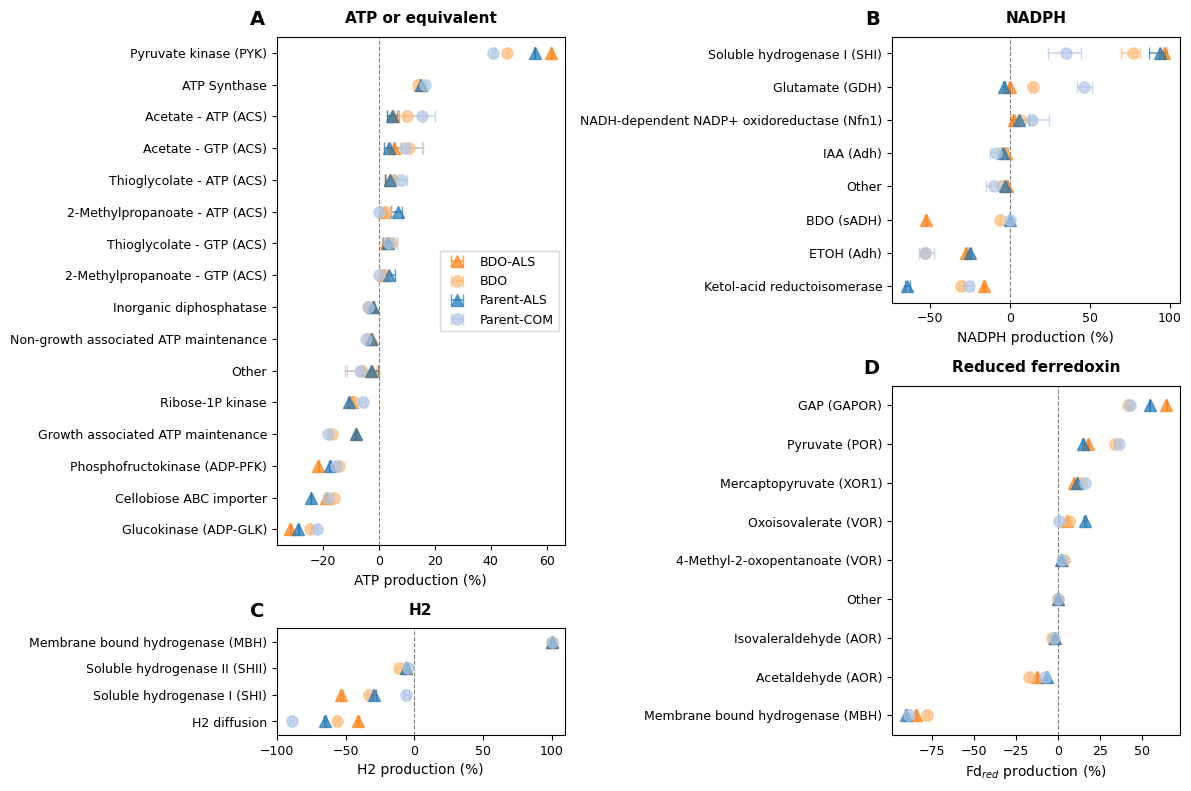

In [50]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os

# Define configurations for each panel with manual labels
panel_configs = {
    'A': {'target_id': 'Phosphorylation', 'threshold': 3, 'use_percentage': True,
          'title': 'ATP or equivalent', 'xlabel': 'ATP production (%)'},
    'C': {'target_id': 'C00282', 'threshold': 0.0, 'use_percentage': True,
          'title': 'H2', 'xlabel': 'H2 production (%)'},
    'D': {'target_id': 'C00138', 'threshold': 3, 'use_percentage': True,
          'title': 'Reduced ferredoxin', 'xlabel': 'Fd$_{red}$ production (%)'},
    'B': {'target_id': 'C00005', 'threshold': 3, 'use_percentage': True,
          'title': 'NADPH', 'xlabel': 'NADPH production (%)'},
}

# Define layout using subplot_mosaic syntax
layout = [
    ['A', 'B'],
    ['A', 'D'],
    ['C', 'D'],
]
width_ratios = [1, 1]
height_ratios = [0.5, 0.3, 0.2]
figsize = (12, 8)

# Reaction name mapping
reaction_map = {
    "R07181": "Soluble hydrogenase I (SHI)", "TP_H2": "H2 diffusion",
    "R00700": "Soluble hydrogenase II (SHII)", "mbh": "Membrane bound hydrogenase (MBH)",
    "R07159": "GAP (GAPOR)", "R01196": "Pyruvate (POR)",
    "R07160_H": "Oxoisovalerate (VOR)", "xor1": "Mercaptopyruvate (XOR1)",
    "R08566_H": "4-Methyl-2-oxopentanoate (VOR)", "R01197": "α-ketoglutarate (OGOR)",
    "nfn1": "NADH-dependent NADP+ oxidoreductase (Nfn1)", "AOR_Isovaleraldehyde": "Isovaleraldehyde (AOR)",
    "AOR_acetaldehyde": "Acetaldehyde (AOR)",
    "R00248": "Glutamate (GDH)", "Adh_iaa_nadp": "IAA (Adh)",
    "R00746": "ETOH (Adh)", "R04440": "Ketol-acid reductoisomerase",
    "R02946_Tg_sADH": "BDO (sADH)",
    "R00200": "Pyruvate kinase (PYK)", "atps": "ATP Synthase",
    "R00229": "Acetate - ATP (ACS)", "acs3G": "2-Methylpropanoate - GTP (ACS)",
    "R00229_DASH_G": "Acetate - GTP (ACS)", "acs9": "Thioglycolate - ATP (ACS)",
    "acs3": "2-Methylpropanoate - ATP (ACS)", "acs9G": "Thioglycolate - GTP (ACS)",
    "acs4G": "Isovalerate - GTP (ACS)", "NGAM": "Non-growth associated ATP maintenance",
    "GAM_biomass": "Growth associated ATP maintenance", "R11535": "Ribose-1P kinase",
    "R05805": "Phosphofructokinase (ADP-PFK)", "cellobioseABC": "Cellobiose ABC importer",
    "R05804": "Glucokinase (ADP-GLK)",
    "R00004": "Inorganic diphosphatase"
}

# Aesthetic mappings
colors = sns.color_palette("tab20", n_colors=4)
bdo_colors = {'MW698': colors[2], 'MW697': colors[3]}
non_bdo_colors = {'MW268': colors[0], 'COM1c': colors[1]}
color_map = {**bdo_colors, **non_bdo_colors}

marker_map = {'MW698': '^', 'MW697': 'o', 'MW268': '^', 'COM1c': 'o'}
label_map = {'MW698': 'BDO-ALS', 'MW697': 'BDO', 'MW268': 'Parent-ALS', 'COM1c': 'Parent-COM'}


def process_panel_data(target_id, threshold, use_percentage):
    """Process data for a single panel, returning median, Q1, Q3 per reaction per strain."""
    
    median_data = []
    q1_data = []
    q3_data = []

    for strain in samples.keys():
        if target_id == "Phosphorylation":
            df_mM_cpd = get_phosphorylation_contribution(
                samples[strain], models[strain]
            )
        else:
            df_mM_cpd = get_stoichiometric_contribution(
                samples[strain], target_id, models[strain]
            )

        if use_percentage:
            df_mM_cpd = 100*df_mM_cpd.apply(transform_to_scaled_proportion, axis=1)

        # Compute median, Q1, Q3 across samples (rows = samples, cols = reactions)
        median_series = df_mM_cpd.median().replace(0, np.nan).dropna()
        q1_series   = df_mM_cpd.quantile(0.25).reindex(median_series.index)
        q3_series   = df_mM_cpd.quantile(0.75).reindex(median_series.index)

        median_series.name = strain
        q1_series.name   = strain
        q3_series.name   = strain

        median_data.append(median_series)
        q1_data.append(q1_series)
        q3_data.append(q3_series)

    median_df = pd.concat(median_data, axis=1)
    q1_df   = pd.concat(q1_data,   axis=1)
    q3_df   = pd.concat(q3_data,   axis=1)

    # Filter by threshold (based on median)
    mask_below = (median_df.abs() <= threshold).all(axis=1)
    
    def aggregate(df):
        major = df[~mask_below].copy()
        minor = df[mask_below].copy()
        other_row = minor.sum(axis=0).to_frame().T
        other_row.index = ['Other']
        if not (other_row == 0).all().all():
            return pd.concat([major, other_row]).replace(np.nan, 0)
        return major.replace(np.nan, 0)

    combined_median = aggregate(median_df)
    combined_q1   = aggregate(q1_df)
    combined_q3   = aggregate(q3_df)

    # Sort rows by extreme value of median
    def get_extreme_value(row):
        abs_vals = row.abs()
        max_idx = abs_vals.idxmax()
        return row[max_idx]

    extreme_values = combined_median.apply(get_extreme_value, axis=1)
    sort_order = extreme_values.sort_values(ascending=True).index

    combined_median = combined_median.loc[sort_order]
    combined_q1   = combined_q1.loc[sort_order]
    combined_q3   = combined_q3.loc[sort_order]

    # Melt each to long format and merge
    def melt_df(df, value_name):
        melted = df.reset_index().melt(id_vars="index", value_name=value_name)
        melted['label'] = melted['index'].map(reaction_map).fillna(melted['index'])
        return melted

    plot_median = melt_df(combined_median, 'value')
    plot_q1   = melt_df(combined_q1,   'q1')
    plot_q3   = melt_df(combined_q3,   'q3')

    # Merge into a single dataframe
    plot_df = plot_median.copy()
    plot_df['q1'] = plot_q1['q1'].values
    plot_df['q3'] = plot_q3['q3'].values

    return plot_df, combined_median


# Create figure
fig, axs = plt.subplot_mosaic(layout, width_ratios=width_ratios,
                              height_ratios=height_ratios, figsize=figsize)

first_panel = True
save_it = []
for panel_label, config in panel_configs.items():
    if panel_label not in axs:
        continue

    ax = axs[panel_label]

    plot_df, combined_df = process_panel_data(
        config['target_id'], config['threshold'], config['use_percentage']
    )
    save_it.append([plot_df, combined_df])

    if config['target_id'] == "Phosphorylation":
        label = "Phosphorylation"
    else:
        label = getattr(cobra_model.metabolites, config['target_id']).name

    # Plot each strain with IQR error bars
    for strain in ['MW698', 'MW697', 'MW268', 'COM1c']:
        strain_data = plot_df[plot_df['variable'] == strain].copy()

        # Compute asymmetric error bars: distance from median to Q1 and Q3
        xerr_low  = (strain_data['value'] - strain_data['q1']).clip(lower=0).values
        xerr_high = (strain_data['q3'] - strain_data['value']).clip(lower=0).values

        ax.errorbar(
            x=strain_data['value'],
            y=strain_data['label'],
            xerr=[xerr_low, xerr_high],
            fmt=marker_map[strain],        # marker style
            color=color_map[strain],
            markersize=8,
            alpha=0.7,
            capsize=4,                     # width of the error bar caps
            capthick=1.0,
            elinewidth=1.2,
            label=label_map[strain] if first_panel else "",
        )

    n_reactions = len(plot_df['label'].unique())
    fixed_margin = 0.5
    ax.set_ylim(-fixed_margin, n_reactions - 1 + fixed_margin)

    ax.axvline(0, color="grey", ls="--", zorder=0, linewidth=0.8)

    if 'xlabel' in config:
        ax.set_xlabel(config['xlabel'])
    elif config['use_percentage']:
        ax.set_xlabel(f'{label} flux (%)', fontsize=10)
    else:
        ax.set_xlabel(f'{label} flux (mM)', fontsize=10)

    ax.set_ylabel('', fontsize=10)
    
    if 'title' in config:
        ax.set_title(config['title'], fontsize=11, pad=10, fontweight='bold')
    ax.tick_params(axis='both', labelsize=9)

    if first_panel:
        ax.legend(loc='center right', fontsize=9, frameon=True, fancybox=False)
        first_panel = False

plt.tight_layout()

# Add panel labels
for panel_label, config in panel_configs.items():
    if panel_label not in axs:
        continue
    ax = axs[panel_label]

    # Get the bounding box of the axes in figure coordinates
    bb = ax.get_position()  # returns Bbox with x0, y0, x1, y1 in figure fraction

    # Place label at top-left of axes, with a small offset
    x_fig = bb.x0 - 0.01   # nudge left
    y_fig = bb.y1 + 0.01   # nudge above top edge

    fig.text(
        x_fig, y_fig,
        panel_label,
        fontsize=14,
        fontweight='bold',
        va='bottom',   # anchor bottom of text to the y coordinate
        ha='right',
        transform=fig.transFigure
    )

plt.savefig(os.path.join(outdir, 'Fig_X_energy_balance.png'),
            dpi=300, bbox_inches='tight')
plt.show()

In [19]:
save_it[3][1]

,MW698,MW697,MW268,COM1c
R04440,-15.865977,-30.540942,-63.835848,-25.364907
R00746,-27.209724,-52.828770,-24.649617,-52.720862
R02946_Tg_sADH,-52.283999,-5.832616,0.000000,0.000000
Other,-1.628266,-4.503595,-2.945005,-9.521920
Adh_iaa_nadp,-2.111685,-4.282548,-3.855168,-8.278210
nfn1,2.890310,7.302197,5.604365,13.800132
R00248,0.014607,14.452192,-3.474915,46.254276
R07181,96.466982,77.246593,93.606387,35.453840


In [20]:
outdir

'/work/pi_yingzhang_uri_edu/jvailionis/figs/S2026_Hailey_BDO_manuscript/'

In [21]:
table_a = samples_df.groupby("strain")[["Biomass_Pfu", "GAM_biomass", "R05804", "R00200",
                                         "mbh", "R07181", "R00248", "R01196", "R00226", "R00229", "R00229_DASH_G", "atps",
                                         "nfn1", "R00248", "TP_H2"]].median().T
table_a.index = ["Biomass", "Growth-associated ATP",
                 "Glucokinase", "Pyruvate kinase", "Membrane bound hydrogenase",
                 "Soluble hydrogenase I", "Glutamate dehydrogenase", "Pyruvate ferredoxin oxidoreductase",
                 "Acetolactate synthase", "ACS", "ACS-G", "ATPSYN", "nfn1", "GDH", "H2 diffusion"]
table_a.columns = ["Parent-COM", "Parent-ALS", "BDO", "BDO-ALS"]
table_a["units"] = "mM"
table_a.loc["Biomass", "units"] = "g/L"

table_a.round(4)

,Parent-COM,Parent-ALS,BDO,BDO-ALS,units
Biomass,0.1262,0.0914,0.1460,0.1040,g/L
Growth-associated ATP,9.4341,6.8281,10.9138,7.7729,mM
Glucokinase,11.5655,24.3214,15.9164,29.9992,mM
Pyruvate kinase,21.5576,47.2372,29.7682,58.4075,mM
Membrane bound hydrogenase,33.6524,48.8590,34.9723,53.6117,mM
Soluble hydrogenase I,1.9716,14.3579,11.4970,28.6868,mM
Glutamate dehydrogenase,2.6325,-0.5348,2.1643,0.0043,mM
Pyruvate ferredoxin oxidoreductase,13.7871,8.0606,15.1904,11.3414,mM
Acetolactate synthase,2.1594,16.1678,5.4748,20.4849,mM
ACS,8.1303,4.1321,6.5943,4.9273,mM


In [28]:
print(round(np.log2(2.1643/2.6325), 2))
print(round(np.log2(0.5348/2.6325), 2))
#print(round(np.log2(-1/2.6325), 2))

-0.28
-2.3


# Figure Y: Differential expression analysis results

The differential expression analysis (limma) was performed in a seperate notebook.

In [16]:
limma_results_dir = "/work/pi_yingzhang_uri_edu/jvailionis/data/2025-11-14_metabolomics/limma_DEA_output"
pfu_targeted_limma = pd.read_table(os.path.join(limma_results_dir, "2026-04-05_Pfu_targeted_limma_results.csv"), sep=",", index_col=0)
pfu_untargeted_limma = pd.read_table(os.path.join(limma_results_dir, "2026-04-05_Pfu_untargeted_limma_results.csv"), sep=",", index_col=0)

In [17]:
# Drop replicate data caused by re-analysis of the original targeted data
pfu_targeted_limma = pfu_targeted_limma.drop_duplicates(["logFC", "AveExpr", "t"]).reset_index(drop=True)

### Mapping metabolomics data to metabolites in the model

To map the data, we attempt to find a structural representation of each molecule (inchi string). Then we perform molecular fingerprinting and detect the ones with perfect matches.


There are several tables here that were generated from previous analyses:  

The mapping of JGI metabolite names to inchi strings was performed in `2025-09-25_metabolomics.ipynb` via pubchem querying  

The mapping of model metabolite names to inchi strings is referenced in `2025-04-03_JGI_metabolite_mapping.ipynb`, but the original code for querying these may not exist. This was performed by mapping KEGG IDs to chebi and then getting the inchi strings from chebi. This was done in the context of TMFA data collection.

In [21]:
metabName_to_inchi_mapping = pd.read_table("/home/jason_vailionis_uri_edu/jvailionis/data/2025-11-14_metabolomics/metab_name_search/metab_results.tsv")
modelId_to_inchi_mapping = pd.read_table("/home/jason_vailionis_uri_edu/jvailionis/data/JGI_metabolite_mapping/pfu_abes_inchi_database.tsv")

In [22]:
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
import time
from tqdm import tqdm
import numpy as np

def compute_fingerprints(df, inchi_col='inchi', name_col=None):
    """
    Compute molecular fingerprints from InChI strings
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with InChI strings
    inchi_col : str
        Name of column containing InChI strings
    name_col : str
        Name of column with identifiers (optional)
    
    Returns:
    --------
    pd.DataFrame with columns: name, inchi, mol, fingerprint (only valid mols)
    """
    print(f"Computing fingerprints for {len(df)} molecules...")
    
    working_df = df.copy()
    
    # Convert InChI to molecules
    print("Converting InChI to molecules...")
    working_df['mol'] = [Chem.MolFromInchi(inchi) if pd.notna(inchi) else None 
                         for inchi in tqdm(working_df[inchi_col])]
    
    # Drop molecules that failed to convert
    n_before = len(working_df)
    working_df = working_df.dropna(subset=['mol'])
    n_after = len(working_df)
    if n_before > n_after:
        print(f"Warning: {n_before - n_after} molecules failed to convert from InChI")
    
    # Generate fingerprints
    print("Generating fingerprints...")
    fpgen = AllChem.GetRDKitFPGenerator()
    working_df['fingerprint'] = [fpgen.GetFingerprint(mol) 
                                  for mol in tqdm(working_df['mol'])]
    
    # Select relevant columns
    cols_to_keep = [inchi_col, 'mol', 'fingerprint']
    if name_col and name_col in working_df.columns:
        cols_to_keep.insert(0, name_col)
    
    return working_df


def find_best_matches(query_df, reference_df, 
                     query_name_col='query_name',
                     ref_name_col='label',
                     top_n=5,
                     similarity_threshold=0.0):
    """
    Find best structural matches between query and reference databases
    
    Parameters:
    -----------
    query_df : pd.DataFrame
        Query dataframe with 'fingerprint' column
    reference_df : pd.DataFrame
        Reference dataframe with 'fingerprint' column
    query_name_col : str
        Column name for query identifiers
    ref_name_col : str
        Column name for reference identifiers
    top_n : int
        Number of top matches to keep per query
    similarity_threshold : float
        Minimum Tanimoto similarity to include (0-1)
    
    Returns:
    --------
    pd.DataFrame with columns: query_name, ref_name, tanimoto_similarity
    """
    print(f"\nComputing Tanimoto similarities...")
    print(f"Query metabolites: {len(query_df)}")
    print(f"Reference metabolites: {len(reference_df)}")
    print(f"Total comparisons: {len(query_df) * len(reference_df):,}")
    
    all_matches = []
    
    t0 = time.time()
    
    for i, query_row in tqdm(query_df.iterrows(), total=len(query_df), desc="Comparing"):
        query_fp = query_row['fingerprint']
        query_name = query_row.get(query_name_col, f"Query_{i}")
        
        # Compute similarities to all reference metabolites
        match_data = []
        for j, ref_row in reference_df.iterrows():
            ref_fp = ref_row['fingerprint']
            ref_name = ref_row.get(ref_name_col, f"Ref_{j}")
            
            similarity = DataStructs.TanimotoSimilarity(query_fp, ref_fp)
            
            if similarity >= similarity_threshold:
                match_data.append({
                    'query_name': query_name,
                    'ref_name': ref_name,
                    'tanimoto_similarity': similarity
                })
        
        # Sort by similarity and keep top N
        if match_data:
            match_df = pd.DataFrame(match_data)
            match_df = match_df.sort_values('tanimoto_similarity', ascending=False).head(top_n)
            all_matches.append(match_df)
    
    t1 = time.time()
    print(f"Took {round(t1-t0, 2)} seconds")
    
    # Combine all matches
    if all_matches:
        result_df = pd.concat(all_matches, ignore_index=True)
        return result_df
    else:
        return pd.DataFrame(columns=['query_name', 'ref_name', 'tanimoto_similarity'])


def get_perfect_matches(similarity_df, threshold=1.0):
    """Extract perfect or near-perfect matches"""
    return similarity_df[similarity_df['tanimoto_similarity'] >= threshold]


def main_structure_matching(query_df, reference_df, 
                           query_inchi_col='inchi',
                           ref_inchi_col='inchi',
                           query_name_col='query_name',
                           ref_name_col='label',
                           top_n=5,
                           similarity_threshold=0.5):
    """
    Complete pipeline for structure matching
    """
    print("="*60)
    print("STRUCTURE MATCHING PIPELINE")
    print("="*60)
    
    # Step 1: Prepare query database (PubChem results)
    print("\n[1/3] Preparing query database (PubChem results)...")
    # Only use rows where we found something
    query_with_structure = query_df[query_df['inchi'].notna()].copy()
    print(f"Queries with valid InChI: {len(query_with_structure)}")
    
    query_fp_df = compute_fingerprints(
        query_with_structure, 
        inchi_col=query_inchi_col,
        name_col=query_name_col
    )
    
    # Step 2: Prepare reference database (internal model)
    print(f"\n[2/3] Preparing reference database (reference_df)...")
    ref_with_structure = reference_df[reference_df[ref_inchi_col].notna()].copy()
    print(f"References with valid InChI: {len(ref_with_structure)}")
    
    ref_fp_df = compute_fingerprints(
        ref_with_structure,
        inchi_col=ref_inchi_col,
        name_col=ref_name_col
    )
    
    # Step 3: Find matches
    print(f"\n[3/3] Finding structural matches...")
    similarity_df = find_best_matches(
        query_fp_df,
        ref_fp_df,
        query_name_col=query_name_col,
        ref_name_col=ref_name_col,
        top_n=top_n,
        similarity_threshold=similarity_threshold
    )
    
    return similarity_df, query_fp_df, ref_fp_df

In [23]:
similarity_results, query_fps, ref_fps = main_structure_matching(
    query_df=metabName_to_inchi_mapping,
    reference_df=modelId_to_inchi_mapping,
    query_inchi_col='inchi',
    ref_inchi_col='inchi',
    query_name_col='metabolite_name',
    ref_name_col='name',
    top_n=5,
    similarity_threshold=0.5
)

STRUCTURE MATCHING PIPELINE

[1/3] Preparing query database (PubChem results)...
Queries with valid InChI: 477
Computing fingerprints for 477 molecules...
Converting InChI to molecules...


100%|██████████| 477/477 [00:00<00:00, 1275.98it/s]


Generating fingerprints...


100%|██████████| 477/477 [00:00<00:00, 1656.78it/s]



[2/3] Preparing reference database (reference_df)...
References with valid InChI: 782
Computing fingerprints for 782 molecules...
Converting InChI to molecules...


...

Generating fingerprints...


100%|██████████| 782/782 [00:00<00:00, 804.47it/s] 



[3/3] Finding structural matches...

Computing Tanimoto similarities...
Query metabolites: 477
Reference metabolites: 782
Total comparisons: 373,014


Comparing: 100%|██████████| 477/477 [00:22<00:00, 21.26it/s]


Took 22.44 seconds


Text(0.5, 0, 'Tanimonto similarity score')

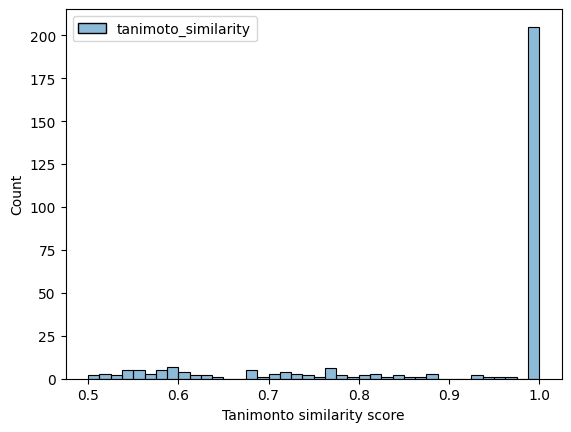

In [24]:
# Histogram of similarity scores
# The high peak at 1 indicates that we can clearly separate matches from non-matches
sns.histplot(similarity_results.groupby("query_name").max("tanimoto_similarity"),
             bins=40)
plt.xlabel("Tanimonto similarity score")

Overview of the tables and their identifying keys:
1. `modelId_to_inchi_mapping`
    * id: psamm model ID
    * name: psamm model name
2. `metabName_to_inchi_mapping`
    * metabolite_name: JGI internal name (or name from MASST for untargeted)
    * query_name: Cleaned version of the JGI internal name, used to query pubchem
3. `similarity_results`
    * **The columns for this depend on which ones you chose when calling the main_structure_matching function**.
    Based on this structure: `query_name_col='metabolite_name', ref_name_col='name'` the columns would be the following:  
    * `query_name`: `metabolite_name` from `metabName_to_inchi_mapping`
    * `ref_name`: `name` from `modelId_to_inchi_mapping`
4. `pfu_targeted_limma`:
    * `metabolite`: JGI internal name.  
    Corresponds to `metabolite_name` from `metabName_to_inchi_mapping`
5. `pfu_untargeted_limma`:
    * `propagated_annotation`: Automatic name from MASST annotation.
    Corresponds to `metabolite_name` from `metabName_to_inchi_mapping`
    

Mapping procedure:

0. Filter similarity_results to only include perfect matches
1. Merge similarity_results with modelId_to_inchi_mapping, mapping 'ref_name' to 'name'. Drop the inchi columns
2. Merge pfu_targeted_limma with table from 1, mapping 'metabolite' to 'query_name'
3. Merge pfu_untargeted_limma with table from 1, mapping 'propagated_annotation' to 'query_name'

In [25]:
perfect_matches = similarity_results.query("tanimoto_similarity > 0.999")

In [26]:
model_to_JGI_map = (modelId_to_inchi_mapping
    .merge(perfect_matches, left_on="name", right_on="ref_name")
    .drop(columns=["name", "inchi", "inchi_key", "neutral_inchi",
                   "neutral_inchi_key", "tanimoto_similarity"])
    .rename(columns={"query_name": "JGI_name", "ref_name": "model_name",
                     "id": "model_id"})
                    )

Next, I manually curated some of the IDs (particularly important for sugars). 
For some sugars, metabolomics won't be able to distinguish them (e.g. mannose vs glucose). I chose the version that we expect to see in the model (e.g. mannose in the metabolomics data maps to glucose in the model).

In [27]:
# Save the data to a tsv
model_to_JGI_map.drop_duplicates(["JGI_name"]).to_csv(
    os.path.join(outdir, "model_to_JGI_map.tsv"), sep="\t")

### Read in the model mapping results
So that you don't need to re-compute every time

In [18]:
# After editing the table manually, reread it
model_to_JGI_map = pd.read_table(os.path.join(outdir, "model_to_JGI_map_edited.tsv"),
                                 sep="\t", index_col=0)

In [19]:
# Priority is used to weight higher quality annotations first
targ_annot = pfu_targeted_limma.merge(model_to_JGI_map, left_on="metabolite", right_on="JGI_name")
targ_annot["priority"] = 0

untarg_annot = pfu_untargeted_limma.merge(model_to_JGI_map, left_on="propagated_annotation", right_on="JGI_name")
untarg_annot["priority"] = 1
untarg_annot.loc[untarg_annot["annotation_source"] == "propagated", "priority"] = 2

In [20]:
# Merging targeted and untargeted annotations
limma_results = pd.concat([targ_annot, untarg_annot]).drop(columns=[
    "fullpath", "feature_id", "metabolite", "adduct", "row.m.z",
    "row.retention.time", "propagated_annotation"])

limma_results_dedupe = (limma_results
                        .sort_values(["priority", "adj.P.Val"])
                        .drop_duplicates("model_id", keep="first"))

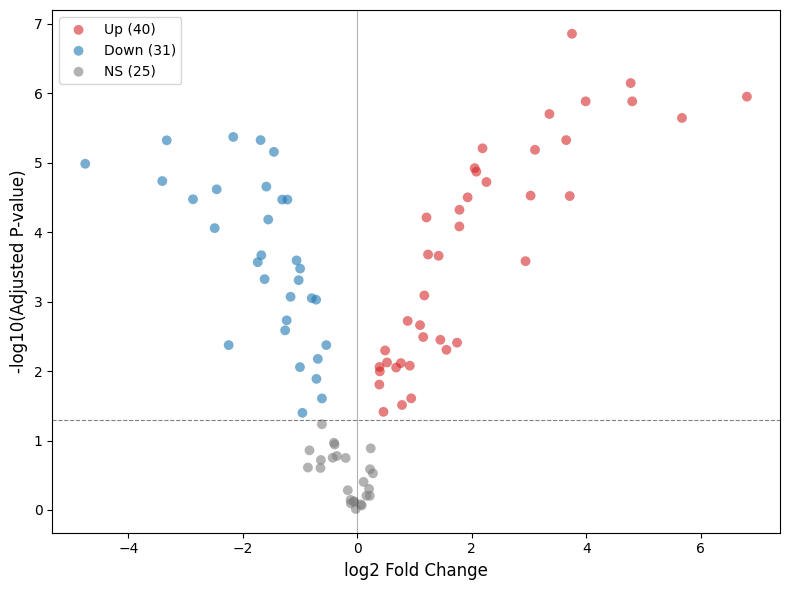

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prep palette and labels
pal = sns.color_palette("tab10")
color_map = {
    'Up': pal[3],      # Red
    'Down': pal[0],    # Blue
    'NS': pal[7]    # Grey
}

sig_counts = limma_results_dedupe['significance'].value_counts()
label_map = {
    'Up': f'Up ({sig_counts.get("Up", 0)})',
    'Down': f'Down ({sig_counts.get("Down", 0)})',
    'NS': f'NS ({sig_counts.get("NS", 0)})'
}

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
for category in ['Up', 'Down', 'NS']:
    mask = limma_results_dedupe['significance'] == category
    data = limma_results_dedupe[mask]
    
    ax.scatter(
        x=data['logFC'],
        y=-np.log10(data['adj.P.Val']),
        color=color_map[category],
        label=label_map[category],
        alpha=0.6, s=50, edgecolors='none'
    )

ax.axhline(y=-np.log10(0.05), color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)

ax.set_xlabel('log2 Fold Change', fontsize=12)
ax.set_ylabel('-log10(Adjusted P-value)', fontsize=12)
ax.legend(loc='upper left', frameon=True)

plt.tight_layout()
#plt.savefig('volcano_plot.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
limma_results_dedupe.to_csv(os.path.join(outdir, "limma_results_dedupe.tsv"), sep="\t")

In [23]:
pathway_classification = {
    'Glycolysis/Central Carbon': [
        'Phosphoenolpyruvate (PEP)',
        '3-Phospho-D-glycerate (3PG)',
        '2-Phospho-D-glycerate (2PG)',
        'Glyceraldehyde 3-phosphate (GAP)',
        'D-Glucose 6-phosphate (G6P)',
        'D-Fructose 6-phosphate (F6P)',
        'Pyruvate (Pyr)',
        'D-Glucose',
        'Acetyl-CoA (AcCoA)',
        'Isocitrate',
        'Fumarate',
        'L-Malate',
        'Acetoin'
    ],
    
    'Purine Metabolism': [
        'Guanine',
        'Hypoxanthine',
        'Adenine',
        'AMP',
        'Adenosine',
        'Inosine',
        'Guanosine',
        'ADP',
        'dAMP'
    ],
    
    'Pyrimidine Metabolism': [
        'Cytosine',
        'Uracil',
        'Cytidine',
        'Thymine',
        'Deoxycytidine',
        'Thymidine',
        'Uridine',
        'Orotate'
    ],
    
    'NAD/Nicotinamide': [
        'NADP',
        'NAD',
        'Nicotinamide'
    ],
    
    'Vitamins': [
        'Thiamine',
        'Riboflavin',
        'Biotin',
        'Pantothenate',
        'Pyridoxine'
    ],
    
    'Polyamines and SAM-related': [
        'L-2-Aminoadipate',
        'Putrescine',
        'Spermine',
        'Agmatine',
        'L-Citrulline (Clt)',
        'L-Lysine (lys-L)',
        'L-Proline (Pro-L)',
        'L-Arginine (Arg-L)',
        'L-Methionine (Met-L)',
        'L-Ornithine (Orn)',
        '5-Methylthioadenosine',
        'S-Adenosyl-L-methionine (SAM)'
    ],
    
    'Lipid Precursors': [
        '(R)-Mevalonate (MEV)',
        'myo-Inositol',
    ],
    
    'Branched-Chain Amino Acids': [
        'L-Isoleucine (Ile-L)',
        'L-Leucine (Leu-L)',
        '4-Methyl-2-oxopentanoate',
        'Citraconic acid'
    ],
    
    'Aromatic Amino Acids': [
        'L-Phenylalanine (Phe-L)',
        'L-Tyrosine (Tyr-L)',
        'L-Tryptophan (Trp-L)',
        'Anthranilate',
        'Indole-3-acetate',
    ],
    
    'Other Amino Acids': [
        'L-Aspartic acid (Asp-L)',
        'L-Histidine (His-L)',
        'L-Glutamine (Gln-L)',
        'L-Glutamic acid (Glu-L)',
        'L-Alanine (Ala-L)',
        'L-Homoserine',
        'L-Serine (Ser-L)',
        'L-Asparagine (Asn-L)',
        'L-Glycine (Gly-L)',
        'L-Threonine (Thr-L)',
    ],
    
    'Sugars & Carbohydrates': [
        'Mannitol',
        'Gentiobiose',
        'alpha,alpha-Trehalose',
        'Maltose',
        'Raffinose',
        'Cellobiose',
        'Sucrose',
        'D-Mannose',
        'D-Gluconate'
    ],
    
    'Amino Sugars & Cell Wall': [
        'N-Acetyl-D-glucosamine (GlcNAc)',
        'D-Glucosamine',
        'UDP-N-acetyl-D-glucosamine',
        'UDPglucose'
    ],
}

metabolite_to_pathway = {}
for pathway, metabolites in pathway_classification.items():
    for metabolite in metabolites:
        metabolite_to_pathway[metabolite] = pathway

limma_results_dedupe['pathway'] = limma_results_dedupe['model_name'].map(metabolite_to_pathway)

In [24]:
limma_results_dedupe[pd.isna(limma_results_dedupe.pathway)]

,logFC,AveExpr,t,P.Value,adj.P.Val,B,chemistry,mode,database,CustomStds,variable,significance,model_id,JGI_name,model_name,priority,annotation_source,pathway
31,3.357164,20.414441,17.550371,4.367076e-08,0.000002,9.387161,HILIC,NEG,ISTD,False,peak_height,Up,C00095,fructose_unlabeled,D-Fructose,0,NaN,NaN
153,-2.490324,17.545779,-8.514818,1.672319e-05,0.000088,3.046219,HILIC,NEG,EMA,False,peak_height,Down,C00624,N-acetyl-glutamic_acid,N-Acetyl-L-glutamate,0,NaN,NaN
44,-1.675637,24.628837,-7.375827,5.072827e-05,0.000215,1.844387,HILIC,NEG,EMA,False,peak_height,Down,C00577,glyceraldehyde,D-Glyceraldehyde,0,NaN,NaN
19,-2.245576,20.234766,-4.457375,1.727032e-03,0.004235,-1.957321,HILIC,NEG,ISTD,False,peak_height,Down,C00491,cystine_unlabeled,L-Cystine,0,NaN,NaN
30,0.679206,19.366781,3.854440,4.145161e-03,0.008911,-2.886536,HILIC,POS,EMA,False,peak_height,Up,C00334,4-aminobutanoic_acid,4-Aminobutanoate,0,NaN,NaN
8,0.394258,24.783979,3.749619,4.851852e-03,0.010118,-3.052480,HILIC,POS,EMA,False,peak_height,Up,C00719,betaine,Glycine betaine,0,NaN,NaN
37,0.781930,19.003261,2.931285,1.735263e-02,0.030819,-4.377977,HILIC,NEG,EMA,False,peak_height,Up,C00156,4-hydroxybenzoic_acid,4-Hydroxybenzoate (4HBZ),0,NaN,NaN
45,-0.642318,16.061279,-1.440147,1.848667e-01,0.248526,-6.664616,HILIC,NEG,EMA,False,peak_height,NS,C00258,glyceric_acid,(R)-Glycerate (GlycR),0,NaN,NaN
14,0.110018,21.313259,1.071187,3.129354e-01,0.394606,-7.099690,HILIC,POS,EMA,False,peak_height,NS,C00114,choline,Choline,0,NaN,NaN
134,-0.115857,17.480886,-0.482228,6.415588e-01,0.715056,-7.571609,C18,POS,EMA,True,peak_height,NS,C00164,Acetoacetate,acetoacetate,0,NaN,NaN


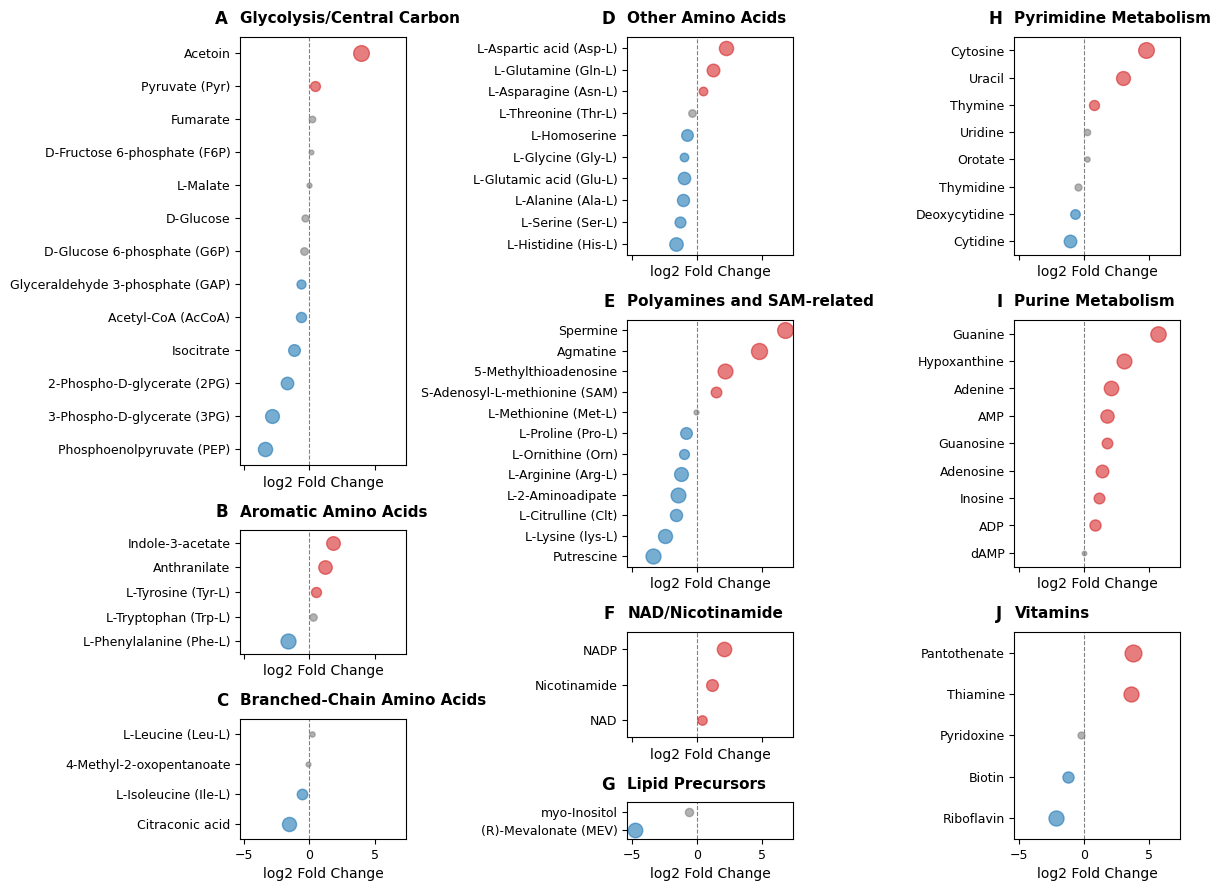

In [48]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pal = sns.color_palette("tab10")
color_map = {
    'Up': pal[3],
    'Down': pal[0],
    'NS': pal[7]
}

#pathways = limma_results_dedupe['pathway'].unique()
pathways_custom_order = ["Glycolysis/Central Carbon", "Aromatic Amino Acids", "Branched-Chain Amino Acids",
                         "Other Amino Acids", "Polyamines and SAM-related", "NAD/Nicotinamide",
                         "Lipid Precursors", "Pyrimidine Metabolism", "Purine Metabolism", "Vitamins"]

panel_configs = {chr(65+i): pathway for i, pathway in enumerate(pathways_custom_order)}

layout = [
    ['A', 'D', 'H'],
    ['A', 'E', 'I'],
    ['B', 'E', 'I'],
    ['B', 'F', 'J'],
    ['C', 'F', 'J'],
    ['C', 'G', 'J'],
]

width_ratios = [1, 1, 1]
height_ratios = [0.6, 0.4, 0.1, 0.06, 0.05, 0.1]
figsize = (12, 9)

fig, axs = plt.subplot_mosaic(layout, 
                              width_ratios=width_ratios,
                              height_ratios=height_ratios,
                              figsize=figsize,
                              sharex=True)

for panel_label, pathway in panel_configs.items():
    if panel_label not in axs:
        continue
    
    ax = axs[panel_label]
    
    plot_df = limma_results_dedupe[limma_results_dedupe['pathway'] == pathway].copy()
    plot_df['size'] = 10 + -np.log10(plot_df['adj.P.Val']) * 20
    plot_df = plot_df.sort_values("logFC")
    
    for _, row in plot_df.iterrows():
        ax.scatter(
            x=row['logFC'],
            y=row['model_name'],
            color=color_map[row['significance']],
            s=row['size'],
            alpha=0.6,
            label=row['significance']
        )
    
    n_reactions = len(plot_df['model_name'].unique())
    fixed_margin = 0.5  # Fixed margin in data units
    ax.set_ylim(-fixed_margin, n_reactions - 1 + fixed_margin)
    
    ax.axvline(0, color="grey", ls="--", zorder=0, linewidth=0.8)
    ax.set_xlabel('log2 Fold Change', fontsize=10)
    ax.set_ylabel('', fontsize=10)
    ax.set_title(pathway, fontsize=11, pad=10, fontweight='bold', loc='left')
    ax.tick_params(axis='both', labelsize=9)

plt.tight_layout()

# Add panel labels
for panel_label, config in panel_configs.items():
    if panel_label not in axs:
        continue
    ax = axs[panel_label]

    # Get the bounding box of the axes in figure coordinates
    bb = ax.get_position()  # returns Bbox with x0, y0, x1, y1 in figure fraction

    # Place label at top-left of axes, with a small offset
    x_fig = bb.x0 - 0.01   # nudge left
    y_fig = bb.y1 + 0.01   # nudge above top edge

    fig.text(
        x_fig, y_fig,
        panel_label,
        fontsize=12,
        fontweight='bold',
        va='bottom',   # anchor bottom of text to the y coordinate
        ha='right',
        transform=fig.transFigure
    )
    
plt.savefig(os.path.join(outdir, 'Fig_Y_metabolome_changes.png'),
            dpi=300, bbox_inches='tight')
plt.show()

In [47]:
os.path.join(outdir, 'Fig_Y_metabolome_changes.png')

'/work/pi_yingzhang_uri_edu/jvailionis/figs/S2026_Hailey_BDO_manuscript/Fig_Y_metabolome_changes.png'

# Figure Z: Network plot!!

In [31]:
import re
from collections import defaultdict

def psamm_to_cobra_id(s: str) -> str:
    """Apply character replacements for package compatibility."""
    renames = {
        ".": "_DOT_",
        "(": "_LPAREN_",
        ")": "_RPAREN_",
        "-": "_DASH_",
        "[": "_LSQBKT",
        "]": "_RSQBKT",
        ",": "_COMMA_",
        ":": "_COLON_",
        ">": "_GT_",
        "<": "_LT",
        "/": "_FLASH",
        "\\": "_BSLASH",
        "+": "_PLUS_",
        "=": "_EQ_",
        " ": "_SPACE_",
        "'": "_SQUOT_",
        '"': "_DQUOT_",
    }
    
    result = s
    for char, replacement in renames.items():
        result = result.replace(char, replacement)
    return result

def parse_formula(formula: str) -> dict:
    """Parse chemical formula string to element counts."""
    pattern = r'([A-Z][a-z]?)(\d*)'
    matches = re.findall(pattern, formula)
    
    result = defaultdict(int)
    for element, count in matches:
        count = int(count) if count else 1
        result[element] += count
    
    return dict(result)

In [32]:
limma_results_dedupe.to_csv("/work/pi_yingzhang_uri_edu/jvailionis/data/2026-02-13_primarypairs/NODE_DATA.csv")

In [33]:
import matplotlib.colors as mcolors

coolwarm = plt.get_cmap('bwr')
color_min = coolwarm(0.0)
color_max = coolwarm(1.0)
coolwarm_black = mcolors.LinearSegmentedColormap.from_list(
    "coolwarm_black", [color_min, "black", color_max]
)

coolwarm_grey = mcolors.LinearSegmentedColormap.from_list(
    "coolwarm_grey", [color_min, "lightgrey", color_max]
)

In [35]:
outdir

'/work/pi_yingzhang_uri_edu/jvailionis/figs/S2026_Hailey_BDO_manuscript/'

/home/jason_vailionis_uri_edu/.conda/envs/Py-3.10/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


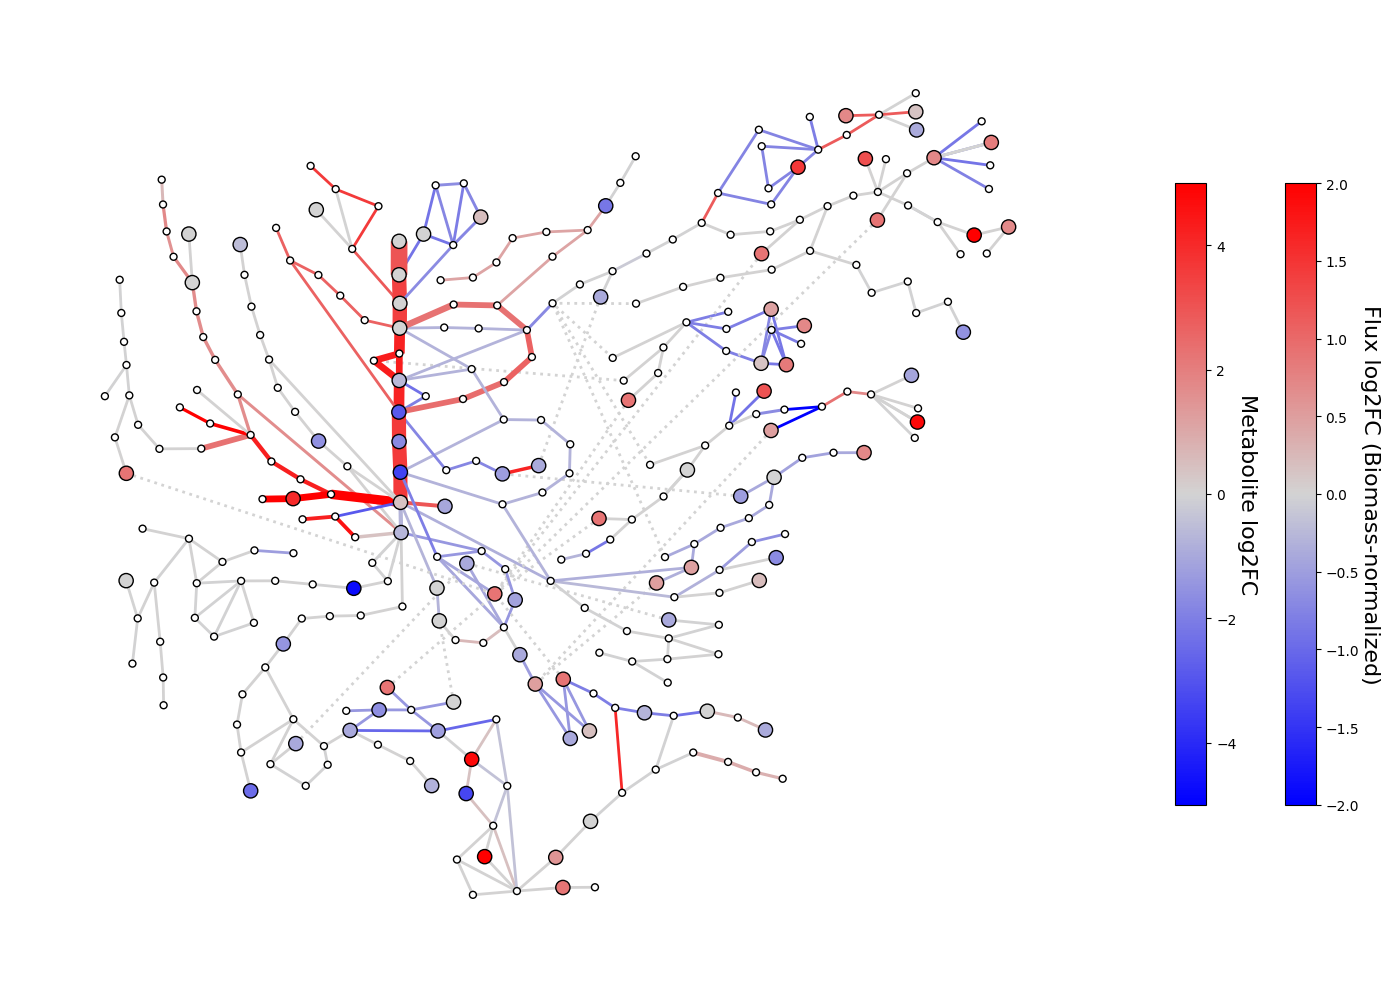

In [34]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
import colorcet as cc

# =============== PARAMETERS ====================
node_size_has_data = 105
node_size_no_data = 25      # If you want to shrink points with no data
node_edgewidths = 1       # Width of the circles around the nodes
node_edge_color = "black"
node_notsig_color = "lightgrey"
node_nodata_color = "white"

edge_width_min = 2          # Minimum line width
edge_width_scaling = 10
edge_color_bounds = (-2, 2)
node_color_bounds = (-5, 5)
group1 = "MW698"
group2 = "COM1c"
normalize_by = "Biomass_Pfu"
default_edge_color = "lightgrey"

node_cmap = coolwarm_grey
edge_cmap = coolwarm_grey

# ========== LOAD NETWORK AND POSITIONS ==========
edited_network_path = "/work/pi_yingzhang_uri_edu/jvailionis/data/2026-02-13_primarypairs/GRAPH.graphml"
G = nx.read_graphml(edited_network_path)

node_positions = "/work/pi_yingzhang_uri_edu/jvailionis/data/2026-02-13_primarypairs/NODE_POSITIONS.csv"
node_table = pd.read_csv(node_positions, index_col=0)
node_table.index = node_table.index.astype("str")

# Set node positions from CSV
for node in G.nodes():
    if node in node_table.index:
        G.nodes[node]['x'] = node_table.loc[node, 'x']
        G.nodes[node]['y'] = node_table.loc[node, 'y']

# Create position dictionary for drawing (flip y-axis for plotting)
pos = {node: (node_table.loc[node, 'x'], -node_table.loc[node, 'y'])
       for node in G.nodes() if node in node_table.index}

## ========== UPDATE NODE ATTRIBUTES WITH LIMMA RESULTS ==========
#limma_dict = limma_results_dedupe.set_index('model_name')['logFC'].to_dict()
#limma_sig_dict = limma_results_dedupe.set_index('model_name')['significance'].to_dict()
#
#for node, node_data in G.nodes(data=True):
#    if node_data["name"] in limma_dict:
#        G.nodes[node]['log2_fold_change'] = limma_dict[node_data["name"]]
#        G.nodes[node]['significance'] = limma_sig_dict[node_data["name"]]
#    else:
#        G.nodes[node]['log2_fold_change'] = "None"
#        G.nodes[node]['significance'] = "None"

# ========== CALCULATE FLUX FOLD CHANGES FOR EDGES ==========

# Calculate normalized mean fluxes
if normalize_by:
    group1_norm = samples[group1].div(samples[group1][normalize_by], axis=0).median()
    group2_norm = samples[group2].div(samples[group2][normalize_by], axis=0).median()
else:
    group1_norm = samples[group1].median()
    group2_norm = samples[group2].median()

# Calculate log2 fold change for fluxes
flux_log2fc = np.log2((group1_norm + 1e-9) / (group2_norm + 1e-9)).dropna()
#flux_log2fc = (np.abs(group1_norm) - np.abs(group2_norm))

# Add flux fold changes to edges
for u, v, edge_data in G.edges(data=True):
    if 'reaction' in edge_data:
        rxn_id = psamm_to_cobra_id(edge_data['reaction'])
        if rxn_id in flux_log2fc.index:
            G.edges[u, v, 0]["logFC"] = flux_log2fc[rxn_id]
            

# ========== SETUP EDGE STYLING ==========

# Edge styles (solid vs dotted for links)
edge_styles = []
for u, v, edge_data in G.edges(data=True):
    if edge_data.get('edge_type') == 'link':
        edge_styles.append('dotted')
    else:
        edge_styles.append('solid')

# Edge colors (based on flux fold change)
edge_values = []
edge_has_value = []

for u, v, edge_data in G.edges(data=True):
    if 'logFC' in edge_data:
        edge_values.append(edge_data['logFC'])
        edge_has_value.append(True)
    else:
        edge_values.append(0)
        edge_has_value.append(False)

# Color mapper for edges
if edge_color_bounds == "auto":
    edge_color_val = max(np.abs([min(edge_values), max(edge_values)]))
    edge_color_vmin, edge_color_vmax = (-edge_color_val, edge_color_val)
else:
    edge_color_vmin, edge_color_vmax = edge_color_bounds

edge_norm = TwoSlopeNorm(vmin=edge_color_vmin, vcenter=0, vmax=edge_color_vmax)

edge_colors = []
for i, (u, v) in enumerate(G.edges()):
    if edge_has_value[i]:
        edge_colors.append(edge_cmap(edge_norm(edge_values[i])))
    else:
        edge_colors.append(default_edge_color)

# Edge widths (based on carbon flux)
ignore_width = ["SerK", "R00582"]
edge_widths_raw = []
edge_width_has_value = []

for u, v, edge_data in G.edges(data=True):
    if ('reaction' in edge_data) and ('element_transfer' in edge_data):
        rxn_id = psamm_to_cobra_id(edge_data['reaction'])
        molecules = parse_formula(edge_data['element_transfer'])
        
        if rxn_id not in ignore_width and rxn_id in samples[group1].columns:
            carbon_flux = molecules["C"] * np.abs(samples[group1][rxn_id].median())
            edge_widths_raw.append(carbon_flux)
            edge_width_has_value.append(True)
        else:
            edge_widths_raw.append(0)
            edge_width_has_value.append(False)
    else:
        edge_widths_raw.append(0)
        edge_width_has_value.append(False)

# Normalize widths to range based on parameters
edge_widths_array = np.array(edge_widths_raw)
if any(edge_width_has_value):
    width_min = edge_widths_array[edge_width_has_value].min()
    width_max = edge_widths_array[edge_width_has_value].max()
    width_range = width_max - width_min if width_max != width_min else 1
    
    edge_widths = []
    for i, w in enumerate(edge_widths_raw):
        if edge_width_has_value[i]:
            normalized = (w - width_min) / width_range
            edge_widths.append(edge_width_min + normalized * edge_width_scaling)
        else:
            edge_widths.append(edge_width_min)
else:
    edge_widths = [edge_width_min] * len(edge_widths_raw)

# ========== SETUP NODE COLORS AND SIZES ==========

color_metabolite_data = True

node_values = []
node_has_value = []
node_sizes = []
node_sig = []

for node in G.nodes():
    node_data = G.nodes[node]
    if 'logFC' in node_data and node_data['logFC'] != "None":
        node_values.append(node_data['logFC'])
        node_has_value.append(True)
        node_sizes.append(node_size_has_data)
        node_sig.append(node_data['significance'])
    else:
        node_values.append(0)
        node_has_value.append(False)
        node_sizes.append(node_size_no_data)
        node_sig.append(None)

# Color mapper for nodes
if node_color_bounds == "auto":
    node_color_val = max(np.abs([min(node_values), max(node_values)]))
    node_color_vmin, node_color_vmax = (-node_color_val, node_color_val)
else:
    node_color_vmin, node_color_vmax = node_color_bounds
    
if color_metabolite_data:
    node_norm = TwoSlopeNorm(vmin=node_color_vmin, vcenter=0, vmax=node_color_vmax)
else:
    node_norm = TwoSlopeNorm(vmin=-9999, vcenter=0, vmax=9999)

node_colors = []
for i, node in enumerate(G.nodes()):
    if node_has_value[i] and color_metabolite_data:
        if node_sig[i] == 'NS':
            node_colors.append(node_notsig_color)
        else:
            node_colors.append(node_cmap(node_norm(node_values[i])))
        #node_colors.append(color_map[node_sig[i]])
        
    else:
        node_colors.append(node_nodata_color)

# ========== PLOT ==========
fig, ax = plt.subplots(figsize=(14, 10))

# Draw edges with custom styles and colors
nx.draw_networkx_edges(G, pos, 
                       edge_color=edge_colors,
                       #edge_color="black",
                       width=edge_widths,
                       style=edge_styles,
                       arrows=False,
                       ax=ax)

## Add an inner line layer
#nx.draw_networkx_edges(G, pos, 
#                       edge_color="black",
#                       width=0.5,
#                       style=edge_styles,
#                       arrows=False,
#                       ax=ax)

# Draw nodes with custom colors and sizes
nx.draw_networkx_nodes(G, pos,
                       node_color=node_colors,
                       node_size=node_sizes,
                       edgecolors=node_edge_color,
                       linewidths=node_edgewidths,
                       ax=ax)

# ========== ADD COLORBARS ==========

# Colorbar for edges
if any(edge_has_value):
    sm_edges = cm.ScalarMappable(cmap=edge_cmap, norm=edge_norm)
    sm_edges.set_array([])
    cbar_edges = plt.colorbar(sm_edges, ax=ax, fraction=0.0238, pad=0.06)
    cbar_edges.set_label(f'Flux log2FC (Biomass-normalized)',
                         rotation=270, labelpad=15, fontsize=16)

# Colorbar for nodes
if any(node_has_value):
    sm_nodes = cm.ScalarMappable(cmap=node_cmap, norm=node_norm)
    sm_nodes.set_array([])
    cbar_nodes = plt.colorbar(sm_nodes, ax=ax, fraction=0.026, pad=0.06)
    cbar_nodes.set_label('Metabolite log2FC', rotation=270, labelpad=15, fontsize=16)

plt.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(outdir, 'Fig_Z_network_diagram.png'),
            dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(outdir, 'Fig_Z_network_diagram.svg'),
            dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [35]:
nx.write_graphml(G, "/work/pi_yingzhang_uri_edu/jvailionis/data/2026-02-13_primarypairs/network_split_round3.graphml")

In [36]:
outdir

'/work/pi_yingzhang_uri_edu/jvailionis/figs/S2026_Hailey_BDO_manuscript/'

In [37]:
import plotly.graph_objects as go
import networkx as nx
import numpy as np
from matplotlib.colors import TwoSlopeNorm

# ... [your existing network setup code] ...

# ========== PLOTLY SCALING PARAMETERS ==========
node_size_scale_has_data = 0.2
node_size_scale_no_data = 0.5
edge_width_scale = 1.5

# ========== CREATE INTERACTIVE PLOT WITH PLOTLY ==========

# Create edge traces (lines only, no hover)
edge_traces = []

for u, v, edge_data in G.edges(data=True):
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    
    # Get edge properties
    edge_idx = list(G.edges()).index((u, v))
    color = edge_colors[edge_idx]
    width = edge_widths[edge_idx] * edge_width_scale
    style = edge_styles[edge_idx]
    
    # Convert rgba to rgb string for plotly
    if isinstance(color, tuple) and len(color) == 4:
        color = f'rgba({int(color[0]*255)}, {int(color[1]*255)}, {int(color[2]*255)}, {color[3]})'
    
    edge_trace = go.Scatter(
        x=[x0, x1, None],
        y=[y0, y1, None],
        mode='lines',
        line=dict(
            width=width,
            color=color if edge_has_value[edge_idx] else default_edge_color,
            dash='dot' if style == 'dotted' else 'solid'
        ),
        hoverinfo='skip',  # Skip hover for the line itself
        showlegend=False
    )
    edge_traces.append(edge_trace)

# Create edge HOVER points (invisible markers at midpoint of edges)
edge_hover_x = []
edge_hover_y = []
edge_hover_text = []

for u, v, edge_data in G.edges(data=True):
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    
    # Calculate midpoint
    mid_x = (x0 + x1) / 2
    mid_y = (y0 + y1) / 2
    
    edge_hover_x.append(mid_x)
    edge_hover_y.append(mid_y)
    
    # Get edge properties
    edge_idx = list(G.edges()).index((u, v))
    
    # Prepare hover text for edges
    hover_text = ""
    if 'reaction' in edge_data:
        rxn_id = edge_data['reaction']
        hover_text += f"<b>Reaction:</b> {rxn_id}<br>"
    
    if edge_has_value[edge_idx]:
        log2fc = edge_values[edge_idx]
        hover_text += f"<b>Flux Log2FC:</b> {log2fc:.3f}<br>"
    else:
        hover_text += f"<b>Flux Log2FC:</b> No data<br>"
    
    if 'element_transfer' in edge_data:
        hover_text += f"<b>Transfer:</b> {edge_data['element_transfer']}<br>"
    
    # Add carbon flux info if available
    if edge_idx < len(edge_widths_raw) and edge_width_has_value[edge_idx]:
        carbon_flux = edge_widths_raw[edge_idx]
        hover_text += f"<b>Carbon Flux:</b> {carbon_flux:.2f}<br>"
    
    edge_type = edge_data.get('edge_type', 'reaction')
    hover_text += f"<b>Type:</b> {edge_type}"
    
    edge_hover_text.append(hover_text if hover_text else 'No data')

# Create invisible scatter trace for edge hovers
edge_hover_trace = go.Scatter(
    x=edge_hover_x,
    y=edge_hover_y,
    mode='markers',
    marker=dict(
        size=10,  # Size of the hoverable area
        color='rgba(0,0,0,0)',  # Completely transparent
        line=dict(width=0)
    ),
    hoverinfo='text',
    hovertext=edge_hover_text,
    showlegend=False
)

# Create node trace
node_x = []
node_y = []
node_colors_plotly = []
node_sizes_plotly = []
node_text = []

for i, node in enumerate(G.nodes()):
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    
    # Convert matplotlib color to plotly format
    color = node_colors[i]
    if isinstance(color, tuple) and len(color) == 4:
        color = f'rgba({int(color[0]*255)}, {int(color[1]*255)}, {int(color[2]*255)}, {color[3]})'
    node_colors_plotly.append(color)
    
    # Scale node sizes differently based on whether they have data
    if node_has_value[i]:
        scaled_size = node_sizes[i] * node_size_scale_has_data
    else:
        scaled_size = node_sizes[i] * node_size_scale_no_data
    node_sizes_plotly.append(scaled_size)
    
    # Prepare hover text
    node_data = G.nodes[node]
    node_name = node_data.get('name', node)
    
    hover_text = f"<b>{node_name}</b><br>"
    hover_text += f"<b>ID:</b> {node}<br>"
    
    if node_has_value[i]:
        log2fc = node_values[i]
        significance = node_sig[i]
        hover_text += f"<b>Log2FC:</b> {log2fc:.3f}<br>"
        hover_text += f"<b>Significance:</b> {significance}<br>"
    else:
        hover_text += "<i>No metabolomics data</i><br>"
    
    # Add any other node attributes you want to show
    if 'formula' in node_data:
        hover_text += f"<b>Formula:</b> {node_data['formula']}<br>"
    
    node_text.append(hover_text)

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode='markers',
    hoverinfo='text',
    text=node_text,
    marker=dict(
        size=node_sizes_plotly,
        color=node_colors_plotly,
        line=dict(
            color=node_edge_color,
            width=node_edgewidths
        )
    ),
    showlegend=False
)

# Create figure - ORDER MATTERS! Edges first, then edge hover points, then nodes
fig = go.Figure(data=edge_traces + [edge_hover_trace] + [node_trace])

# Update layout
fig.update_layout(
    title=dict(
        text=f"Interactive Network: {group1} vs {group2}",
        font=dict(size=20)
    ),
    showlegend=False,
    hovermode='closest',  # Now this will work properly!
    margin=dict(b=0, l=0, r=0, t=40),
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    plot_bgcolor='white',
    width=1400,
    height=1000
)

# Save as HTML
fig.write_html(os.path.join(outdir, 'Fig_Z_network_interactive.html'))

In [37]:
import plotly.graph_objects as go
import networkx as nx
import numpy as np
from matplotlib.colors import TwoSlopeNorm
from PIL import Image
import base64
from io import BytesIO

# ========== LOAD BACKGROUND IMAGE ==========
# Path to your hand-drawn annotation image (SVG, PNG, etc.)
annotation_image_path = "/work/pi_yingzhang_uri_edu/jvailionis/figs/S2026_Hailey_BDO_manuscript/Fig_Z_network_diagram_labels.png"
img = Image.open(annotation_image_path)

# Get the bounds of your network for proper image sizing
x_values = [pos[node][0] for node in G.nodes()]
y_values = [pos[node][1] for node in G.nodes()]
x_min, x_max = min(x_values), max(x_values)
y_min, y_max = min(y_values), max(y_values)

node_size_scale_has_data = 0.2
node_size_scale_no_data = 0.5
edge_width_scale = 1.5
# Add some padding
padding = 0.1
x_range = x_max - x_min
y_range = y_max - y_min
x_min -= padding * x_range
x_max += padding * x_range
y_min -= padding * y_range
y_max += padding * y_range

x_manual_shift = 1300
y_manual_shift = 0

# ========== CREATE INTERACTIVE PLOT WITH PLOTLY ==========

# Create edge traces
edge_traces = []

for u, v, edge_data in G.edges(data=True):
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    
    edge_idx = list(G.edges()).index((u, v))
    color = edge_colors[edge_idx]
    width = edge_widths[edge_idx] * edge_width_scale
    style = edge_styles[edge_idx]
    
    if isinstance(color, tuple) and len(color) == 4:
        color = f'rgba({int(color[0]*255)}, {int(color[1]*255)}, {int(color[2]*255)}, {color[3]})'
    
    edge_trace = go.Scatter(
        x=[x0, x1, None],
        y=[y0, y1, None],
        mode='lines',
        line=dict(
            width=width,
            color=color if edge_has_value[edge_idx] else default_edge_color,
            dash='dot' if style == 'dotted' else 'solid'
        ),
        hoverinfo='skip',
        showlegend=False
    )
    edge_traces.append(edge_trace)

# Create edge hover points
edge_hover_x = []
edge_hover_y = []
edge_hover_text = []

for u, v, edge_data in G.edges(data=True):
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    
    mid_x = (x0 + x1) / 2
    mid_y = (y0 + y1) / 2
    
    edge_hover_x.append(mid_x)
    edge_hover_y.append(mid_y)
    
    edge_idx = list(G.edges()).index((u, v))
    
    hover_text = ""
    if 'reaction' in edge_data:
        rxn_id = edge_data['reaction']
        hover_text += f"<b>Reaction:</b> {rxn_id}<br>"
    
    if edge_has_value[edge_idx]:
        log2fc = edge_values[edge_idx]
        hover_text += f"<b>Flux Log2FC:</b> {log2fc:.3f}<br>"
    else:
        hover_text += f"<b>Flux Log2FC:</b> No data<br>"
    
    if 'element_transfer' in edge_data:
        hover_text += f"<b>Transfer:</b> {edge_data['element_transfer']}<br>"
    
    if edge_idx < len(edge_widths_raw) and edge_width_has_value[edge_idx]:
        carbon_flux = edge_widths_raw[edge_idx]
        hover_text += f"<b>Carbon Flux:</b> {carbon_flux:.2f}<br>"
    
    edge_type = edge_data.get('edge_type', 'reaction')
    hover_text += f"<b>Type:</b> {edge_type}"
    
    edge_hover_text.append(hover_text if hover_text else 'No data')

edge_hover_trace = go.Scatter(
    x=edge_hover_x,
    y=edge_hover_y,
    mode='markers',
    marker=dict(
        size=10,
        color='rgba(0,0,0,0)',
        line=dict(width=0)
    ),
    hoverinfo='text',
    hovertext=edge_hover_text,
    showlegend=False
)

# Create node trace
node_x = []
node_y = []
node_colors_plotly = []
node_sizes_plotly = []
node_text = []

for i, node in enumerate(G.nodes()):
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    
    color = node_colors[i]
    if isinstance(color, tuple) and len(color) == 4:
        color = f'rgba({int(color[0]*255)}, {int(color[1]*255)}, {int(color[2]*255)}, {color[3]})'
    node_colors_plotly.append(color)
    
    if node_has_value[i]:
        scaled_size = node_sizes[i] * node_size_scale_has_data
    else:
        scaled_size = node_sizes[i] * node_size_scale_no_data
    node_sizes_plotly.append(scaled_size)
    
    node_data = G.nodes[node]
    node_name = node_data.get('name', node)
    
    hover_text = f"<b>{node_name}</b><br>"
    hover_text += f"<b>ID:</b> {node}<br>"
    
    if node_has_value[i]:
        log2fc = node_values[i]
        significance = node_sig[i]
        hover_text += f"<b>Log2FC:</b> {log2fc:.3f}<br>"
        hover_text += f"<b>Significance:</b> {significance}<br>"
    else:
        hover_text += "<i>No metabolomics data</i><br>"
    
    if 'formula' in node_data:
        hover_text += f"<b>Formula:</b> {node_data['formula']}<br>"
    
    node_text.append(hover_text)

node_trace = go.Scatter(
    x=node_x,
    y=node_y,
    mode='markers',
    hoverinfo='text',
    text=node_text,
    marker=dict(
        size=node_sizes_plotly,
        color=node_colors_plotly,
        line=dict(
            color=node_edge_color,
            width=node_edgewidths
        )
    ),
    showlegend=False
)

# Create figure
fig = go.Figure(data=edge_traces + [edge_hover_trace] + [node_trace])

# ========== ADD BACKGROUND IMAGE ==========
fig.add_layout_image(
    dict(
        source=img,
        xref="x",
        yref="y",
        x=x_min,
        y=y_max,
        sizex=x_max - x_min+x_manual_shift,
        sizey=y_max - y_min+y_manual_shift,
        sizing="stretch",
        opacity=1,
        layer="above"
    )
)

# Update layout
fig.update_layout(
    title=dict(
        text=f"Interactive Network: {group1} vs {group2}",
        font=dict(size=20)
    ),
    showlegend=False,
    hovermode='closest',
    margin=dict(b=0, l=0, r=0, t=40),
    xaxis=dict(
        showgrid=False, 
        zeroline=False, 
        showticklabels=False,
        range=[x_min, x_max]  # Set explicit range for image alignment
    ),
    yaxis=dict(
        showgrid=False, 
        zeroline=False, 
        showticklabels=False,
        range=[y_min, y_max]  # Set explicit range for image alignment
    ),
    plot_bgcolor='white',
    width=1200,
    height=1100
)

# Save as HTML
fig.write_html(os.path.join(outdir, 'Fig_Z_network_interactive_labeled.html'))
#fig.show()
#

In [46]:
import pickle

with open(os.path.join(outdir, "samples_dict.pkl.gz"), 'wb') as f:
    pickle.dump(samples, f)

# To Load
#with open('data_dict.pkl', 'rb') as f:
#    samples = pickle.load(f)

In [42]:
os.path.join(outdir, "samples_dict.pkl")

'/work/pi_yingzhang_uri_edu/jvailionis/figs/S2026_Hailey_BDO_manuscript/samples_dict.pkl'

In [39]:
outdir

'/work/pi_yingzhang_uri_edu/jvailionis/figs/S2026_Hailey_BDO_manuscript/'

In [75]:
abs_quant = pd.read_table("/work/pi_yingzhang_uri_edu/jvailionis/data/2025-11-14_metabolomics/2025-11-14_Abes_Pfu_absolute_quant.tsv")
abs_quant['bound_str'] = abs_quant['lower_bound_mM'].round(3).astype(str) + '–' + abs_quant['upper_bound_mM'].round(4).astype(str)

# Pivot to wide format
wide_df = abs_quant.pivot_table(
    index='metabolite',
    columns='sample_treatment',
    values='bound_str',
    aggfunc='first'  # in case of duplicates
).reset_index()

# Clean up the column index name
wide_df.columns.name = None

wide_df.columns = ["Metabolite", "Ignore1", "Ignore2", "Parent-COM", "BDO-ALS"]
wide_df["units"] = "mM"

wide_df = wide_df[["Metabolite", "Parent-COM", "BDO-ALS", "units"]]

wide_df = wide_df.sort_values("Metabolite")


wide_df.to_csv(os.path.join(outdir, "Supp_table_S3.tsv"), index=False)

In [74]:
outdir

'/work/pi_yingzhang_uri_edu/jvailionis/figs/S2026_Hailey_BDO_manuscript/'

In [73]:
wide_df

,Metabolite,Parent-COM,BDO-ALS,units
0,3-phosphoglycerate,0.074–0.1006,0.024–0.0403,mM
1,ADP,0.0–0.0234,0.0–0.0234,mM
2,AMP,0.222–0.2442,0.276–0.2915,mM
3,ATP,0.0–0.0197,0.0–0.0197,mM
4,Acetoacetate,0.0–0.2473,0.0–0.2473,mM
5,Acetoin,0.0–0.2837,0.872–1.365,mM
6,Acetolactate,0.0–0.1892,0.0–0.1892,mM
7,Acetyl-CoA,0.0–0.0124,0.0–0.0124,mM
8,CoA,0.0–0.013,0.0–0.013,mM
9,Fructose-1_6-bisphosphate,0.0–0.0147,0.0–0.0147,mM
